In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib


df = pd.read_csv("../data/TelcoCustomerChurn.csv") # read data set file
df.head() # Displays first 5 rows to ensure the file is loaded

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info() #Data type and structure checks

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
#Senior citizen (Fixed datatype to numeric)
df['SeniorCitizen'] = df['SeniorCitizen'].astype('boolean')

#Total Charges (Fixed datatype to numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   boolean
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
(df.isnull() | (df == ' ')).sum() #Missing-value analysis

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: Int64

In [5]:
df[df['TotalCharges'].isnull()] #Analyse null entry in TotalCharges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,False,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,False,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,False,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,False,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,False,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,False,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,False,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,False,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,False,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,False,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [6]:
#We found that we can set default value as 0 for TotalCharges (Because may customer not started consuming service yet as Tenure as 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)
(df.isnull() | (df == ' ')).sum() #Verify again for theere is no missing value

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: Int64

In [7]:
df.duplicated().sum() #Duplicate analysis

np.int64(0)

In [8]:
#No duplicate records found

#-------------
# Identify Numerical and categorical feature, Target & ID identification
#-------------
# customerID : Id column can not be feature due to overfitting & Zero Generalisation
# Churn : Target which we want to predict
id_target = ['customerID', 'Churn']

numerical_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

categorical_features = [
    col for col in df.columns
    if (col not in numerical_features and 
       col not in id_target)
]

print("Id column: customerID \n  [Id column can not be feature due to overfitting & Zero Generalisation]")
print("\nTarget: Churn \n  [Target which we want to predict]")
print("\nNumerical features:")
print(numerical_features)
print("\nCategorical features:")
print(categorical_features)

Id column: customerID 
  [Id column can not be feature due to overfitting & Zero Generalisation]

Target: Churn 
  [Target which we want to predict]

Numerical features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [9]:
# Target-variable analysis
target_summary = pd.DataFrame({
    'Count': df['Churn'].value_counts(),
    'Percentage': df['Churn'].value_counts(normalize=True) * 100
})

target_summary

,Count,Percentage
Churn,,
No,5174,73.463013
Yes,1869,26.536987


In [10]:
#-------------
#Data cleaning and preprocessing
#Train/Test Split: Use a 70:30 split for training and testing.
#Random Seed: Set random_state = 42 for reproducibility.
#-------------

# Data cleaning already done by steps above like fix datatype, handled missing and duplicates

# Separate Feature & Target
X = df.drop(['customerID', 'Churn'], axis=1) # Numerical & categorial feature
y = df['Churn'].map({'Yes': 1, 'No': 0})     # Target

# Train/Test Split (70:30, seed=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)


Visualization 1: Customer vs Churn Distribution



[Text(0, 0, '5174'), Text(0, 0, '1869')]

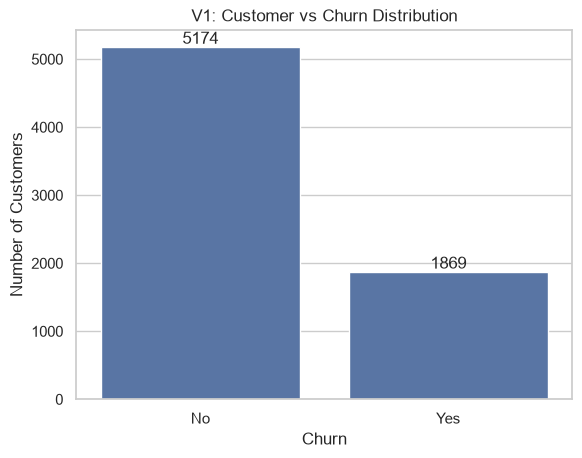

In [11]:
# 2. Exploratory Data Analysis
sns.set_theme(style="whitegrid")

# 1. Churn Distribution
print("Visualization 1: Customer vs Churn Distribution\n")

ax1 = sns.countplot(data=df, x='Churn'); 
ax1.set_title('V1: Customer vs Churn Distribution'); 
ax1.set_ylabel('Number of Customers'); 
ax1.bar_label(ax1.containers[0])


Visualization 2: Customer Churn by Contract Type



[Text(0, 0, '2220'), Text(0, 0, '1307'), Text(0, 0, '1647')]

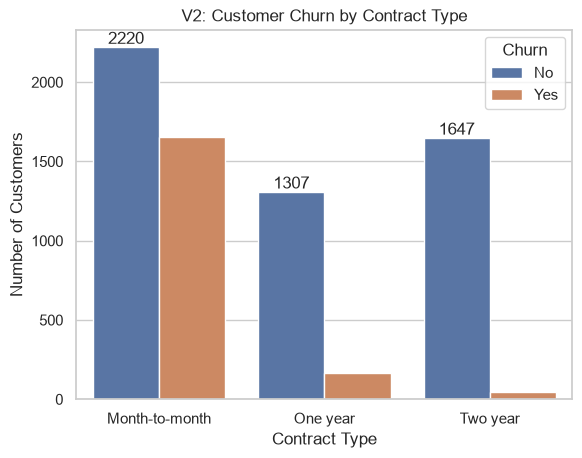

In [12]:
print("\nVisualization 2: Customer Churn by Contract Type\n")

# 2. Customer Churn by Contract Type
ax2 = sns.countplot(data=df, x='Contract', hue='Churn'); 
ax2.set_title('V2: Customer Churn by Contract Type'); 
ax2.set_xlabel('Contract Type')
ax2.set_ylabel('Number of Customers'); 
ax2.bar_label(ax2.containers[0])


Visualization 3: Customer Churn by Internet Service



[Text(0, 0, '1962'), Text(0, 0, '1799'), Text(0, 0, '1413')]

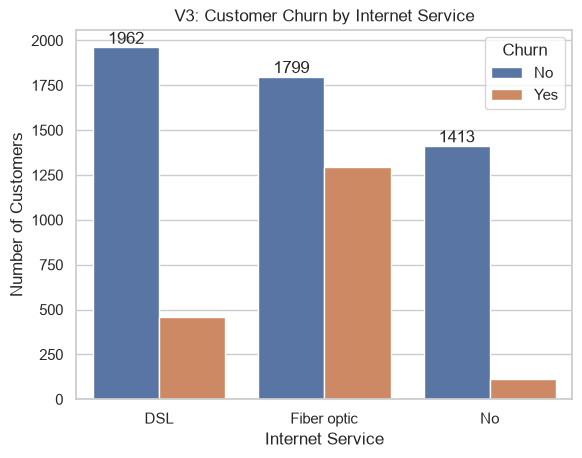

In [13]:
print("\nVisualization 3: Customer Churn by Internet Service\n")

# 3. Customer Churn by Internet Service
ax3 = sns.countplot(data=df, x='InternetService', hue='Churn'); 
ax3.set_title('V3: Customer Churn by Internet Service'); 
ax3.set_xlabel('Internet Service')
ax3.set_ylabel('Number of Customers'); 
ax3.bar_label(ax3.containers[0])


Visualization 4: Churn vs Tenure



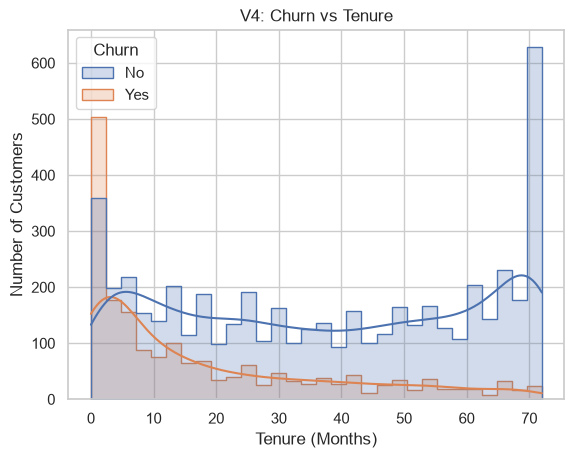

In [14]:
print("\nVisualization 4: Churn vs Tenure\n")

# 4. Tenure Distribution
ax4 = sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=True,
    element='step'
)
ax4.set_title('V4: Churn vs Tenure'); 
ax4.set_xlabel('Tenure (Months)')
ax4.set_ylabel('Number of Customers'); 


Visualization 5: Monthly Charges by Churn



Text(0.5, 1.0, 'V5: Monthly Charges by Churn')

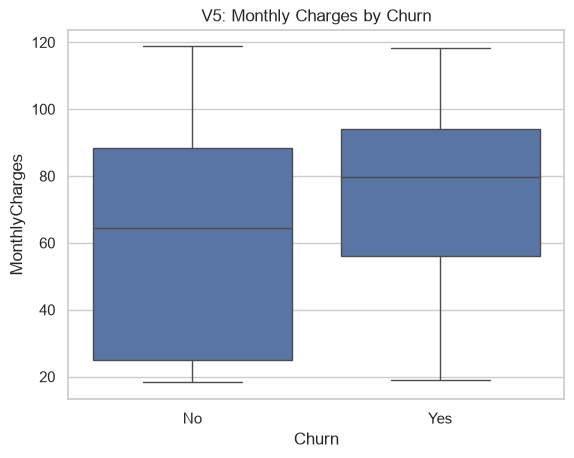

In [16]:
print("\nVisualization 5: Monthly Charges by Churn\n")

# 5. Monthly Charges by Churn
sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
).set_title('V5: Monthly Charges by Churn')


Visualization 6: Tenure vs Monthly Charges by Churn



Text(0.5, 1.0, 'V6: Tenure vs Monthly Charges by Churn')

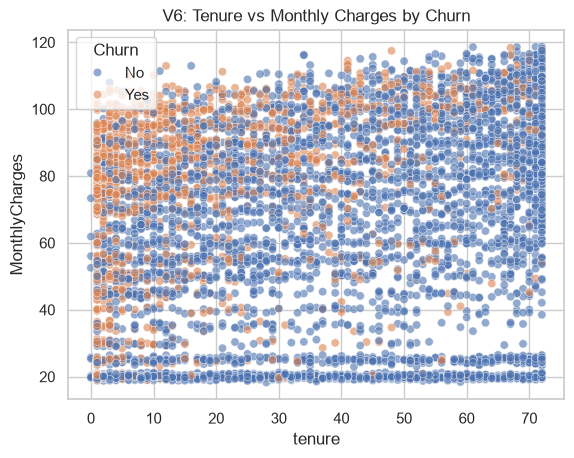

In [17]:
print("\nVisualization 6: Tenure vs Monthly Charges by Churn\n")

# 6. Tenure vs Monthly Charges by Churn
sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    alpha=0.6
).set_title('V6: Tenure vs Monthly Charges by Churn')


Visualization 7: Customer Churn by Payment Method



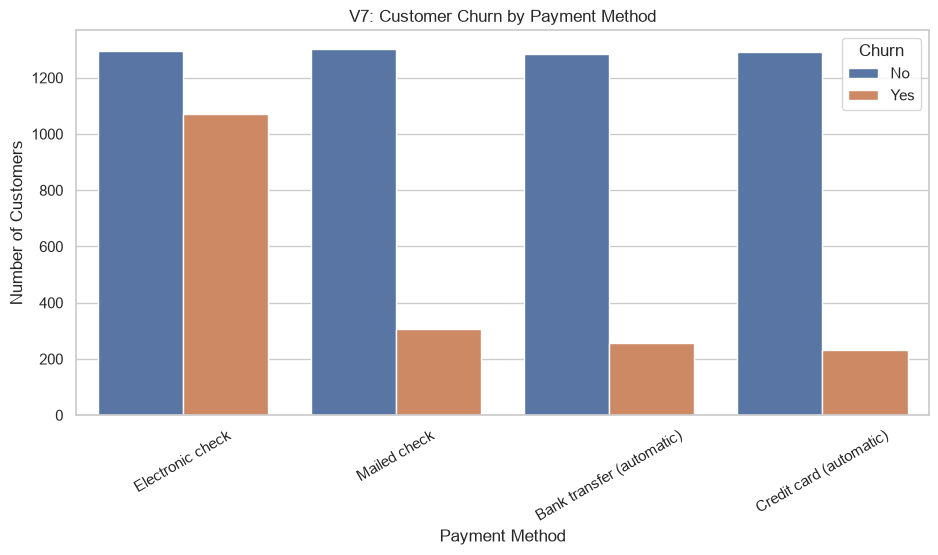

In [19]:
print("\nVisualization 7: Customer Churn by Payment Method\n")

# 6. Customer Churn by Payment Method
plt.figure(figsize=(11, 5))

sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn'
)

plt.title('V7: Customer Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)

plt.show()

In [22]:
## 3. Feature Engineering
# Feature 1: Number of services consumed
# Feature 2: IsAutoPay enabled
# Feature 3: Tenure groups

# 1. Custom Transformer for Feature Engineering
import sys
import os

# Add the parent directory (project root) to the system path
sys.path.append(os.path.abspath('..'))
from feature_transformers import FeatureEngineer 

# 2. Define Features (Based on columns AFTER FeatureEngineer runs)
numerical_features = ['MonthlyCharges', 'TotalCharges', 'TotalServices']
binary_features = ['SeniorCitizen', 'IsAutoPay']

# Dynamically select categorical features + explicitly add the new 'TenureGroup'
categorical_features = [col for col in X_train.columns 
                        if col not in numerical_features + binary_features + ['tenure']] + ['TenureGroup']

# 3. Preprocessor Configuration
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Passes numerical and binary features unchanged
)

# Chain the FeatureEngineer and Preprocessor together
data_pipeline = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', preprocessor)
])

X_train_proc = data_pipeline.fit_transform(X_train)
X_test_proc = data_pipeline.transform(X_test)


In [23]:
feature_names = preprocessor.get_feature_names_out()
df_test_proc = pd.DataFrame(X_train_proc, columns=feature_names)
df_test_proc.head()

,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__PhoneService_No,cat__PhoneService_Yes,cat__MultipleLines_No,cat__MultipleLines_No phone service,...,cat__TenureGroup_13-24,cat__TenureGroup_25-36,cat__TenureGroup_37-48,cat__TenureGroup_49-60,cat__TenureGroup_61+,remainder__SeniorCitizen,remainder__MonthlyCharges,remainder__TotalCharges,remainder__TotalServices,remainder__IsAutoPay
0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,False,80.2,384.25,2,0
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,True,86.85,220.95,3,0
2,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,False,75.15,216.75,2,1
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,False,80.55,4847.05,6,1
4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,False,98.9,1120.95,5,1


In [27]:
## 4. Model Development

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Model 1: Default configuration
dt1 = DecisionTreeClassifier(random_state=42)
dt1.fit(X_train_proc, y_train)
yp1 = dt1.predict(X_test_proc)

# Model 2: Tuned configuration with Handling Class Imbalance (Limits depth to prevent overfitting)
dt2 = DecisionTreeClassifier(max_depth=5, class_weight='balanced', min_samples_split=10, random_state=42)
dt2.fit(X_train_proc, y_train)
yp2 = dt2.predict(X_test_proc)

# Model 3: Random forest with Hyperparameter Tuning + Handling Class Imbalance
# -------------------
rfclassifier = RandomForestClassifier(class_weight='balanced', random_state=42)

# Correct parameter names for a standalone model
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [5, 10, 15]
}

grid_search = GridSearchCV(rfclassifier, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train_proc, y_train)

dt3 = grid_search.best_estimator_
print(f"Best RF Parameters: {grid_search.best_params_}")

yp3 = dt3.predict(X_test_proc)
# -------------------

# 5. Model Evaluation
results = pd.DataFrame({
    'Model': ['Decision Tree 1', 'Decision Tree 2', 'Random forest'],
    'Accuracy': [accuracy_score(y_test, yp1), accuracy_score(y_test, yp2), accuracy_score(y_test, yp3)],
    'Precision': [precision_score(y_test, yp1), precision_score(y_test, yp2), precision_score(y_test, yp3)],
    'Recall': [recall_score(y_test, yp1), recall_score(y_test, yp2), recall_score(y_test, yp3)],
    'F1 Score': [f1_score(y_test, yp1), f1_score(y_test, yp2), f1_score(y_test, yp3)],
    'Confusion Matrix': [confusion_matrix(y_test, yp1), confusion_matrix(y_test, yp2), confusion_matrix(y_test, yp3)],
})

results

Best RF Parameters: {'max_depth': 5, 'min_samples_split': 15, 'n_estimators': 50}


,Model,Accuracy,Precision,Recall,F1 Score,Confusion Matrix
0,Decision Tree 1,0.722196,0.476950,0.479501,0.478222,"[[1257, 295], [292, 269]]"
1,Decision Tree 2,0.725509,0.489503,0.789661,0.604366,"[[1090, 462], [118, 443]]"
2,Random forest,0.734974,0.500560,0.796791,0.614856,"[[1106, 446], [114, 447]]"


In [28]:
# Final Outcome
print('Higher Accuracy and F1 Score')
print('Superior Recall')

final_model = dt3

#From a business perspective, 
#predicting customer churn is critical because acquiring a new customer typically costs significantly more than retaining an existing one.
#Proactive Retention : Identifying high-risk customers before they cancel / churn
#Cost vs. Benefit Optimization
#Resource Allocation : Focus on customer retention budget

Higher Accuracy and F1 Score
Superior Recall


Top 10 Features Influencing Churn:
                                 Feature  Importance
32         cat__Contract_Month-to-month    0.231782
14               cat__OnlineSecurity_No    0.109747
23                  cat__TechSupport_No    0.082824
49              remainder__TotalCharges    0.068193
12     cat__InternetService_Fiber optic    0.061706
41                cat__TenureGroup_0-12    0.058535
34               cat__Contract_Two year    0.058181
39  cat__PaymentMethod_Electronic check    0.038561
48            remainder__MonthlyCharges    0.034474
33               cat__Contract_One year    0.022547

Top 10 Features Influencing Churn Graph:



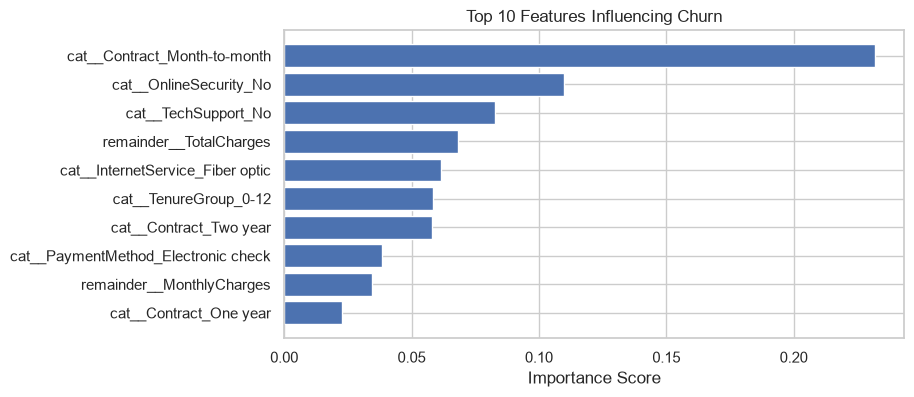

In [29]:
# 6. Model Interpretation

# Extract feature names from the preprocessor step in your pipeline
feature_names = data_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Extract feature importances from your final model (dt2)
importances = final_model.feature_importances_

# Create and display top 10 features
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_features = feat_imp.sort_values(by='Importance', ascending=False).head(10)
print("Top 10 Features Influencing Churn:\n", top_features)

# 1. Visualize Feature Importance
print("\nTop 10 Features Influencing Churn Graph:\n")
plt.figure(figsize=(8, 4))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.title('Top 10 Features Influencing Churn')
plt.xlabel('Importance Score')
plt.show()

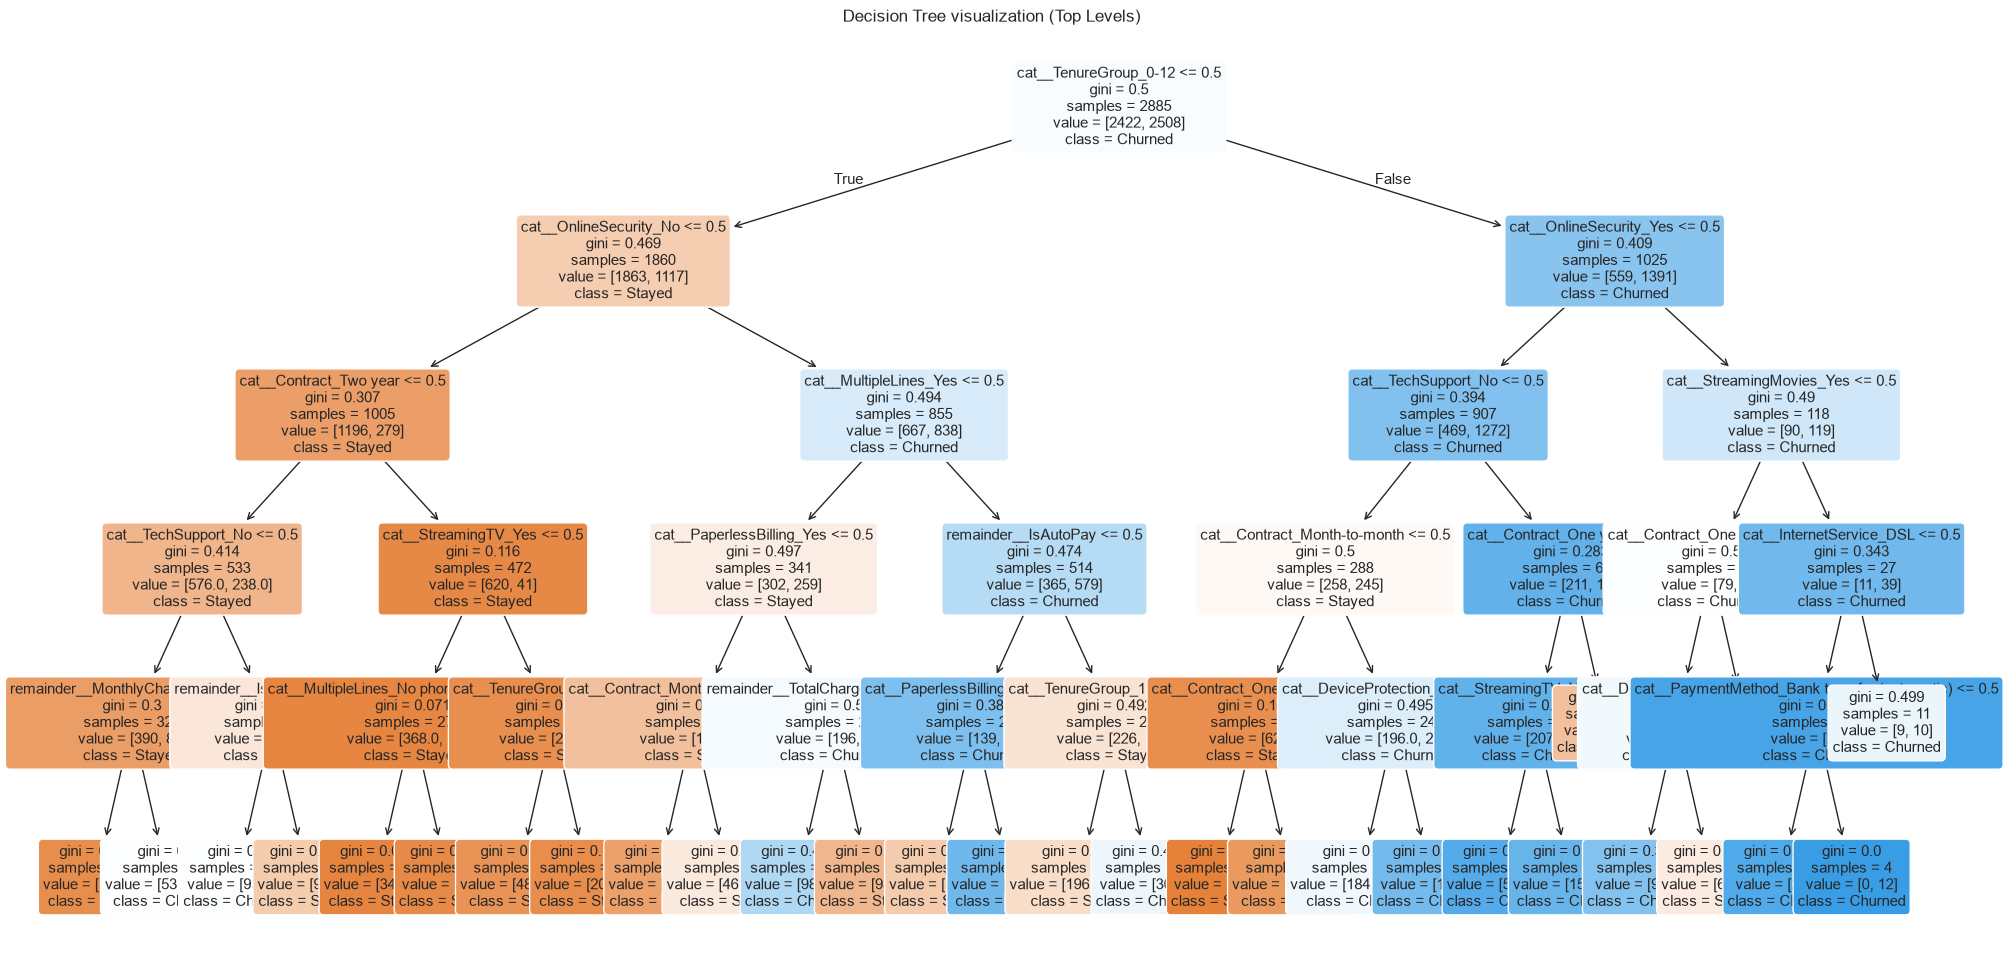

In [30]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 2. Visualize Decision Tree (Limited to depth 5 for readability)
plt.figure(figsize=(24, 12))
plot_tree(final_model.estimators_[0], max_depth=5, feature_names=feature_names, class_names=['Stayed', 'Churned'], filled=True, rounded=True, fontsize=11)
plt.title('Decision Tree visualization (Top Levels)')
plt.show()

In [31]:
##7. Model Saving
import joblib
import os

from sklearn.pipeline import Pipeline

# Combine feature engineering, preprocessing, and the model into ONE pipeline
churn_model = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', final_model)
])

# Fit the entire unified pipeline on the RAW training data
churn_model.fit(X_train, y_train)

# Predict directly on the RAW testing data!
yp_unified = churn_model.predict(X_test)

# Create a model directory if it doesn't exist
save_path = os.path.join('..', 'model', 'churn_model.pkl')
# Ensure the model directory exists before saving
os.makedirs(os.path.dirname(save_path), exist_ok=True)
# Save the unified pipeline to the model folder
joblib.dump(churn_model, save_path)
print("Unified churn_model saved successfully!")

Unified churn_model saved successfully!
